# Potent / Null Subspace Analysis
Iteratively remove direction or disturbance axes from neural population activity
and measure how much of each signal is preserved vs destroyed.

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../../')


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, StratifiedKFold

import pyaldata as pyal

import tools.dsp as dsp
import tools.decoding as decode
from tools.params import colors


In [3]:
SESSIONS = [
    # "M061_2025_03_04_10_00",
    # "M061_2025_03_05_14_00",
    # "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    # "M062_2025_03_20_14_00",
    # "M062_2025_03_21_14_00",
    # "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    "M103_2026_02_18_15_30",
    # "M103_2026_02_19_15_30",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_26_16_00",
]

# Number of PCs to use per area
pc_dict = {"MOp": 30, "SSp": 25, "CP": 30, "VAL": 50}

# Cross-validation
n_splits    = 4

# Direction-removal: fixed number of steps
n_iter      = 3

# Disturbance-removal: max steps + early-stop tolerance
max_iter    = 5
no_dec_tol  = 2    # stop after this many consecutive non-decreasing steps

# Time window parameters (10 ms bins, relative to trial start)
win_size    = 10   # bins (~100 ms)
step        = 1    # stride in bins
t_start     = 125  # first window start bin
t_end       = 400  # last window end bin
alpha_ridge = 0.01


In [4]:
td, _ = dsp.load_and_process_session(SESSIONS[0], std=0.03)
perturb_td = pyal.restrict_to_interval(
    td, start_point_name='idx_sol_on', rel_start=-200, rel_end=300
)
perturb_td = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)
td_drop    = dsp.drop_trials_sem_crosses_zero(perturb_td, std=False)

y_dir  = np.array(td_drop.values_Sol_direction.values.tolist())
y_dist = td_drop.disturb_sum.values.astype(float)
rng    = np.random.default_rng(42)
y_shuf = rng.permutation(y_dist)

_, _counts = np.unique(y_dir, return_counts=True)
chance = _counts.max() / _counts.sum()

cv_dir     = StratifiedKFold(n_splits=n_splits, shuffle=False)
cv_dist    = KFold(n_splits=n_splits, shuffle=False)
win_starts = np.arange(t_start, t_end - win_size + 1, step)

print(f'Session:  {SESSIONS[0]}')
print(f'Trials:   {len(td_drop)}')
print(f'Dir classes: {len(np.unique(y_dir))}, chance: {chance:.3f}')
print(f'Windows:  {len(win_starts)} (bins {t_start}–{t_end})')


fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
['all_spikes', 'CP_spikes', 'MOp_spikes', 'VAL_spikes', 'SSp_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(


Resulting all_spikes ephys data shape is (NxT): (15, 48000)
Resulting CP_spikes ephys data shape is (NxT): (267, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (190, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (126, 48000)
Skipped 8 trials
Otsu immobility threshold: 6.6387
Dropped 70 of 497 rows (14.08%).


/tmp/ipykernel_3737640/3219081557.py:2: UserWarning: Dropping 1 trials because of invalid time indexing. For more information, try warn_per_trial=True
  perturb_td = pyal.restrict_to_interval(


  drop_trials_sem_crosses_zero: by SEM: 292  |  by value: 423  |  kept: 291/424 (68.6%)
Session:  M103_2026_02_18_15_30
Trials:   291
Dir classes: 12, chance: 0.124
Windows:  266 (bins 125–400)


In [5]:
def get_lda_axes(X_epoch, labels):
    """Fit LDA and return orthonormal discriminant axes (n_features, n_classes-1)."""
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_epoch, labels)
    Q, _ = np.linalg.qr(lda.scalings_)
    return Q


def get_ridge_axis(X_epoch, y, alpha=0.01):
    """Fit Ridge and return the normalised weight vector as a (n_features, 1) column."""
    reg = Ridge(alpha)
    reg.fit(X_epoch, y)
    w = reg.coef_.ravel()
    return (w / np.linalg.norm(w))[:, None]


def norm_residual(scores, lb):
    """Normalise final iteration score: 0 = destroyed, 1 = preserved."""
    s0  = np.mean(scores[0])
    sf  = np.mean(scores[-1])
    lb0 = np.mean(lb[0]) if isinstance(lb, list) else lb
    denom = s0 - lb0
    if denom < 1e-9:
        return np.nan
    return (sf - lb0) / denom


def norm_residual_folds(scores, lb):
    """Per-fold normalised residuals — normalise by mean iter-0 and mean lb."""
    s0_folds = np.array(scores[0])
    sf_folds = np.array(scores[-1])
    lb0_mean = np.mean(lb[0]) if isinstance(lb, list) else lb
    denom    = np.mean(s0_folds) - lb0_mean
    if denom < 1e-9:
        return np.full(len(s0_folds), np.nan)
    return (sf_folds - lb0_mean) / denom


In [6]:
results      = {}   # direction-axis removal
results_dist = {}   # disturbance-axis removal

for area_i in pc_dict:
    n_pcs = pc_dict[area_i]
    X_a   = np.stack(td_drop[f'{area_i}_rates_pca'].values)[:, :, :n_pcs]

    # ── 1. Scan all windows (n_rem=0) to locate peak windows ─────────────
    dir_scan, dist_scan = [], []
    for t in win_starts:
        X_w = X_a[:, t:t+win_size, :].mean(axis=1)
        d_f = [LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')
               .fit(X_w[tr], y_dir[tr]).score(X_w[te], y_dir[te])
               for tr, te in cv_dir.split(X_w, y_dir)]
        d_r = [decode.custom_r2_func(y_dist[te],
                   Ridge(alpha_ridge).fit(X_w[tr], y_dist[tr]).predict(X_w[te]))
               for tr, te in cv_dist.split(X_w)]
        dir_scan.append(np.mean(d_f))
        dist_scan.append(np.mean(d_r))

    t_pk_dir  = win_starts[np.argmax(dir_scan)]
    t_pk_dist = win_starts[np.argmax(dist_scan)]
    X_pk_dir  = X_a[:, t_pk_dir:t_pk_dir+win_size,   :].mean(axis=1)
    X_pk_dist = X_a[:, t_pk_dist:t_pk_dist+win_size, :].mean(axis=1)

    dist_lb = np.mean([
        decode.custom_r2_func(y_shuf[te],
            Ridge(alpha_ridge).fit(X_pk_dist[tr], y_dist[tr]).predict(X_pk_dist[te]))
        for tr, te in cv_dist.split(X_pk_dist)
    ])

    print(f'{area_i}  peak dir window: bin {t_pk_dir} ({(t_pk_dir-200)*0.01:.2f}s)  '
          f'peak dist window: bin {t_pk_dist} ({(t_pk_dist-200)*0.01:.2f}s)')

    # ── 2. Direction-axis removal (0 .. n_iter, from scratch each step) ──
    dir_steps,  dir_steps_s  = [], []
    dist_steps, dist_steps_s = [], []

    for n_rem in range(n_iter + 1):
        X_d = X_pk_dir.copy()
        X_s = X_pk_dist.copy()
        for _ in range(n_rem):
            ax_lda = get_lda_axes(X_d, y_dir)
            X_d    = X_d @ (np.eye(n_pcs) - ax_lda @ ax_lda.T)
            ax_lda = get_lda_axes(X_s, y_dir)
            X_s    = X_s @ (np.eye(n_pcs) - ax_lda @ ax_lda.T)

        d_f = [LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')
               .fit(X_d[tr], y_dir[tr]).score(X_d[te], y_dir[te])
               for tr, te in cv_dir.split(X_d, y_dir)]
        d_r = [decode.custom_r2_func(y_dist[te],
                   Ridge(alpha_ridge).fit(X_s[tr], y_dist[tr]).predict(X_s[te]))
               for tr, te in cv_dist.split(X_s)]
        dir_steps.append(np.mean(d_f));   dir_steps_s.append(np.std(d_f))
        dist_steps.append(np.mean(d_r));  dist_steps_s.append(np.std(d_r))

    results[area_i] = dict(
        dir_steps=np.array(dir_steps),   dir_steps_s=np.array(dir_steps_s),
        dist_steps=np.array(dist_steps), dist_steps_s=np.array(dist_steps_s),
        chance=chance, dist_lb=dist_lb,
    )
    print(f'  dir-removal:  dir  = {[f"{v:.3f}" for v in dir_steps]}')
    print(f'  dir-removal:  dist = {[f"{v:.3f}" for v in dist_steps]}')

    # ── 3. Disturbance-axis removal (incremental, early stop) ────────────
    X_d_curr = X_pk_dir.copy()
    X_s_curr = X_pk_dist.copy()
    dir_steps_d,  dir_steps_d_s  = [], []
    dist_steps_d, dist_steps_d_s = [], []
    no_dec = 0

    for n_rem in range(max_iter + 1):
        d_f = [LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')
               .fit(X_d_curr[tr], y_dir[tr]).score(X_d_curr[te], y_dir[te])
               for tr, te in cv_dir.split(X_d_curr, y_dir)]
        d_r = [decode.custom_r2_func(y_dist[te],
                   Ridge(alpha_ridge).fit(X_s_curr[tr], y_dist[tr]).predict(X_s_curr[te]))
               for tr, te in cv_dist.split(X_s_curr)]
        dir_steps_d.append(np.mean(d_f));   dir_steps_d_s.append(np.std(d_f))
        dist_steps_d.append(np.mean(d_r));  dist_steps_d_s.append(np.std(d_r))

        if n_rem >= 1:
            no_dec = no_dec + 1 if dist_steps_d[-1] >= dist_steps_d[-2] - 0.01 else 0
            if no_dec >= no_dec_tol:
                print(f'  {area_i}: early stop at iter {n_rem}')
                break
        if n_rem == max_iter:
            break

        ax_dist  = get_ridge_axis(X_s_curr, y_dist, alpha=alpha_ridge)
        P        = np.eye(n_pcs) - ax_dist @ ax_dist.T
        X_d_curr = X_d_curr @ P
        X_s_curr = X_s_curr @ P

    results_dist[area_i] = dict(
        dir_steps=np.array(dir_steps_d),   dir_steps_s=np.array(dir_steps_d_s),
        dist_steps=np.array(dist_steps_d), dist_steps_s=np.array(dist_steps_d_s),
        chance=chance, dist_lb=dist_lb,
    )
    print(f'  dist-removal: dir  = {[f"{v:.3f}" for v in dir_steps_d]}')
    print(f'  dist-removal: dist = {[f"{v:.3f}" for v in dist_steps_d]}')


MOp  peak dir window: bin 209 (0.09s)  peak dist window: bin 221 (0.21s)
  dir-removal:  dir  = ['0.529', '0.234', '0.189', '0.134']
  dir-removal:  dist = ['0.460', '0.369', '0.369', '0.371']
  dist-removal: dir  = ['0.529', '0.508', '0.505', '0.505', '0.481', '0.481']
  dist-removal: dist = ['0.460', '0.251', '0.251', '0.148', '0.055', '0.045']
SSp  peak dir window: bin 217 (0.17s)  peak dist window: bin 218 (0.18s)
  dir-removal:  dir  = ['0.316', '0.107', '0.134', '0.151']
  dir-removal:  dist = ['0.366', '0.280', '0.280', '0.281']
  SSp: early stop at iter 5
  dist-removal: dir  = ['0.316', '0.313', '0.299', '0.299', '0.299', '0.299']
  dist-removal: dist = ['0.366', '0.166', '0.166', '0.013', '0.008', '0.009']
CP  peak dir window: bin 220 (0.20s)  peak dist window: bin 247 (0.47s)
  dir-removal:  dir  = ['0.275', '0.089', '0.055', '0.048']
  dir-removal:  dist = ['0.238', '0.140', '0.140', '0.115']
  CP: early stop at iter 3
  dist-removal: dir  = ['0.275', '0.265', '0.251', '0.2

Direction | dir removal              MOp    nr=0.026 +/- 0.039
Direction | dir removal              SSp    nr=0.144 +/- 0.106
Direction | dir removal              CP     nr=-0.498 +/- 0.124
Direction | dir removal              VAL    nr=-0.411 +/- 0.037
Disturbance | dir removal            MOp    nr=0.796 +/- 0.018
Disturbance | dir removal            SSp    nr=0.760 +/- 0.058
Disturbance | dir removal            CP     nr=0.462 +/- 0.046
Disturbance | dir removal            VAL    nr=0.742 +/- 0.074
Direction | dist removal             MOp    nr=0.882 +/- 0.057
Direction | dist removal             SSp    nr=0.911 +/- 0.121
Direction | dist removal             CP     nr=0.840 +/- 0.118
Direction | dist removal             VAL    nr=0.853 +/- 0.168
Disturbance | dist removal           MOp    nr=0.043 +/- 0.023
Disturbance | dist removal           SSp    nr=-0.004 +/- 0.017
Disturbance | dist removal           CP     nr=0.027 +/- 0.039
Disturbance | dist removal           VAL    nr=-0.05

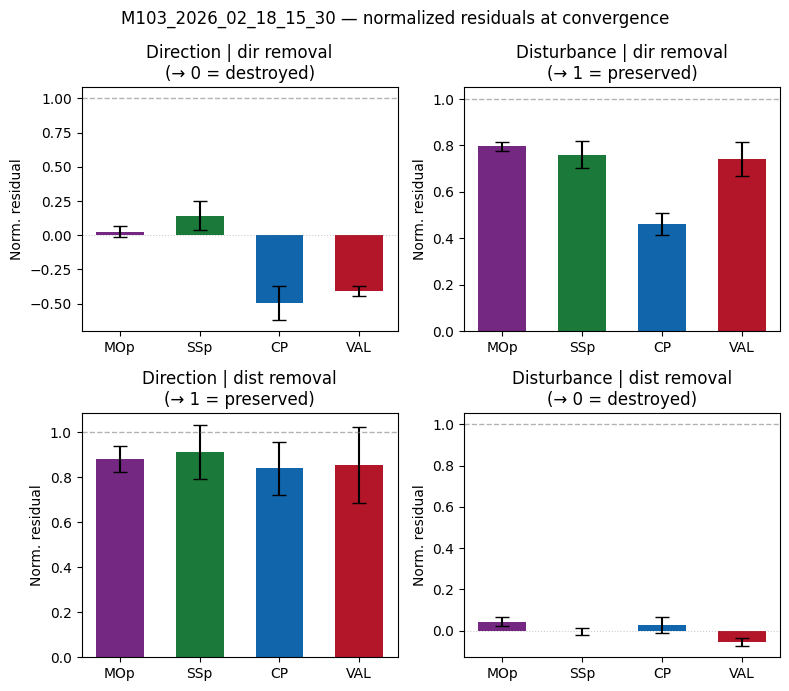

In [7]:
areas_list  = list(pc_dict.keys())
area_colors = [getattr(colors, a) for a in areas_list]

# (row, col, results_dict, score_key, std_key, lb_key, title)
panels = [
    (0, 0, results,      'dir_steps',  'dir_steps_s',  'chance',
     'Direction | dir removal\n(\u2192 0 = destroyed)'),
    (0, 1, results,      'dist_steps', 'dist_steps_s', 'dist_lb',
     'Disturbance | dir removal\n(\u2192 1 = preserved)'),
    (1, 0, results_dist, 'dir_steps',  'dir_steps_s',  'chance',
     'Direction | dist removal\n(\u2192 1 = preserved)'),
    (1, 1, results_dist, 'dist_steps', 'dist_steps_s', 'dist_lb',
     'Disturbance | dist removal\n(\u2192 0 = destroyed)'),
]

fig, axs = plt.subplots(2, 2, figsize=(8, 7))
fig.suptitle(f'{SESSIONS[0]} \u2014 normalized residuals at convergence', fontsize=12)

for row, col, res_dict, sk, sk_s, lb_key, title in panels:
    ax = axs[row, col]
    nrs, sems = [], []
    for area_i in areas_list:
        r     = res_dict[area_i]
        lb    = r[lb_key]
        nr    = norm_residual(r[sk], lb)
        denom = r[sk][0] - (lb if np.isscalar(lb) else np.mean(lb))
        sem   = (r[sk_s][-1] / np.sqrt(n_splits)) / abs(denom) if abs(denom) > 1e-9 else np.nan
        nrs.append(nr)
        sems.append(sem)

    xs = np.arange(len(areas_list))
    ax.bar(xs, nrs, yerr=sems, color=area_colors, width=0.6,
           capsize=5, error_kw=dict(lw=1.5))
    ax.axhline(1, color='gray', ls='--', lw=1, alpha=0.6)
    ax.axhline(0, color='gray', ls=':', lw=0.8, alpha=0.4)
    ax.set_xticks(xs)
    ax.set_xticklabels(areas_list)
    ax.set_ylabel('Norm. residual')
    ax.set_title(title)

    short = title.split('\n')[0]
    for area_i, nr, sem in zip(areas_list, nrs, sems):
        print(f'{short:<35s}  {area_i:5s}  nr={nr:.3f} +/- {sem:.3f}')

plt.tight_layout()
plt.show()
